In [15]:
import pandas as pd

df = pd.read_csv("accidents_weather_ca_merged.csv")

X = df[["temp_f", "humidity", "visibility", "wind_speed"]]
y = df["Severity"]

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

In [17]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

Tree 1 - Gini

In [18]:
dt_gini = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)

dt_gini.fit(X_train, y_train)

y_pred_gini = dt_gini.predict(X_test)

print("Gini Tree Accuracy:", accuracy_score(y_test, y_pred_gini))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_gini))

Gini Tree Accuracy: 0.62

Confusion Matrix:
 [[81 14  0]
 [42 12  0]
 [ 1  0  0]]


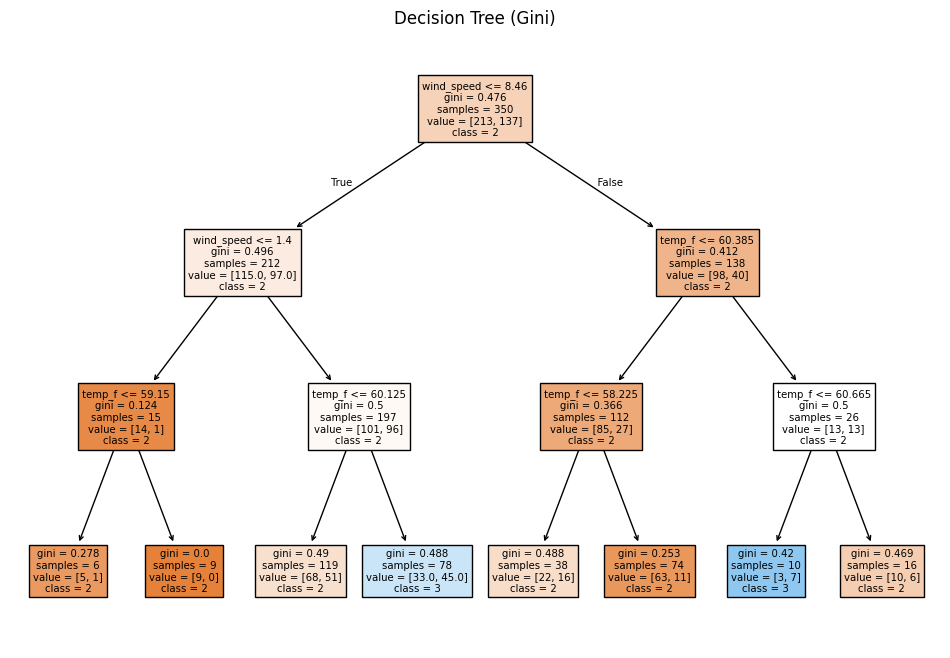

In [21]:
plt.figure(figsize=(12,8))
plot_tree(
    dt_gini,
    feature_names=X.columns,
    class_names=[str(c) for c in sorted(y.unique())],
    filled=True
)
plt.title("Decision Tree (Gini)")
plt.show()

Tree 2 - Entropy

In [19]:
dt_entropy = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    random_state=42
)

dt_entropy.fit(X_train, y_train)

y_pred_entropy = dt_entropy.predict(X_test)

print("Entropy Tree Accuracy:", accuracy_score(y_test, y_pred_entropy))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_entropy))

Entropy Tree Accuracy: 0.64

Confusion Matrix:
 [[95  0  0]
 [53  1  0]
 [ 1  0  0]]


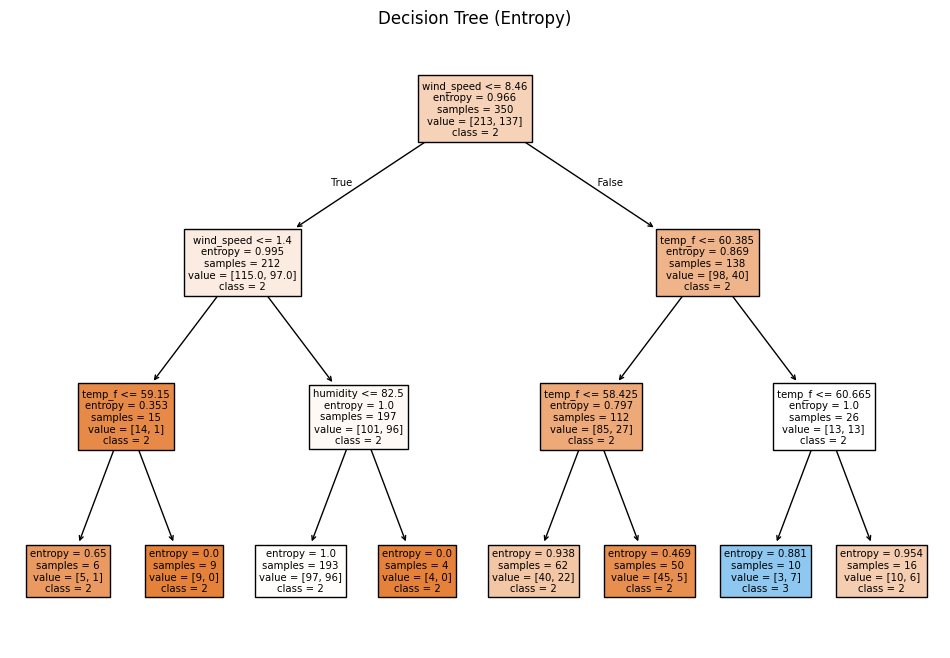

In [22]:
plt.figure(figsize=(12,8))
plot_tree(
    dt_entropy,
    feature_names=X.columns,
    class_names=[str(c) for c in sorted(y.unique())],
    filled=True
)
plt.title("Decision Tree (Entropy)")
plt.show()

TREE 3 — DIFFERENT ROOT (REMOVE FEATURE)

In [20]:
X_alt = df[["temp_f", "humidity", "visibility"]]

X_train_alt, X_test_alt, y_train_alt, y_test_alt = train_test_split(
    X_alt, y,
    test_size=0.3,
    random_state=42
)

dt_alt = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

dt_alt.fit(X_train_alt, y_train_alt)

y_pred_alt = dt_alt.predict(X_test_alt)

print("Alt Tree Accuracy:", accuracy_score(y_test_alt, y_pred_alt))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_alt, y_pred_alt))

Alt Tree Accuracy: 0.5933333333333334

Confusion Matrix:
 [[78 17  0]
 [43 11  0]
 [ 1  0  0]]


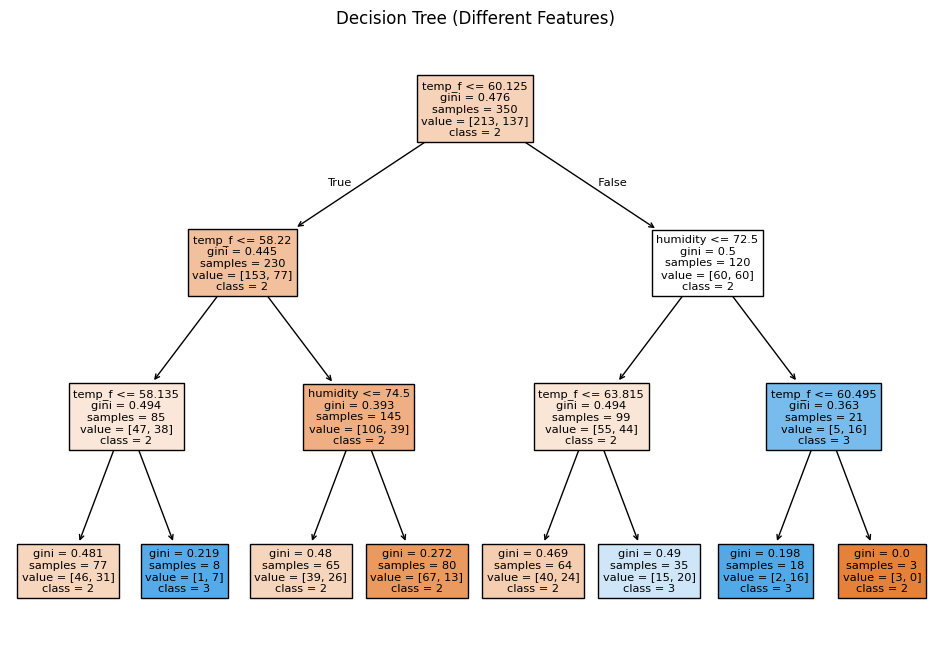

In [23]:
plt.figure(figsize=(12,8))
plot_tree(
    dt_alt,
    feature_names=X_alt.columns,
    class_names=[str(c) for c in sorted(y.unique())],
    filled=True
)
plt.title("Decision Tree (Different Features)")
plt.show()

In [25]:
import pandas as pd

results_dt = pd.DataFrame({
    "Model": ["Gini", "Entropy", "Alt Features"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_gini),
        accuracy_score(y_test, y_pred_entropy),
        accuracy_score(y_test_alt, y_pred_alt)
    ]
})

results_dt

,Model,Accuracy
0,Gini,0.620000
1,Entropy,0.640000
2,Alt Features,0.593333
